In [489]:
# # Features Nhóm Demographics
# customerID: ID duy nhất của khách hàng, nên drop vì không mang thông tin dự đoán
# gender (Male/Female): Giới tính, ít ảnh hưởng churn nhưng dùng kiểm tra bias
# * SeniorCitizen (0/1): Người cao tuổi (1=Yes), thường churn cao hơn do nhu cầu khác biệt
# Partner (Yes/No): Có vợ/chồng/đối tác, liên quan retention gia đình
# Dependents (Yes/No): Có người phụ thuộc, ảnh hưởng chi phí và loyalty

# # Features Nhóm Services
# (check) * tenure (1-72 tháng): Thời gian gắn bó, numerical quan trọng nhất - tenure cao thì churn thấp (correlation âm mạnh)
# PhoneService (Yes/No): Có dùng phone, hầu hết Yes
# MultipleLines (Yes/No/No phone service): Dùng nhiều line phone, có thể tăng churn nếu phí cao
# InternetService (DSL/Fiber optic/None): Fiber optic thường churn cao do tốc độ/chi phí
# OnlineSecurity/OnlineBackup/DeviceProtection/TechSupport/StreamingTV/StreamingMovies (Yes/No/No internet service): Các add-on internet; No internet service = không dùng, thường churn thấp hơn vì ít dịch vụ

# # Features Nhóm Account
# Contract (Month-to-month/One year/Two year): Hợp đồng ngắn hạn (Month-to-month) churn cao nhất do dễ hủy
# PaperlessBilling (Yes/No): Hóa đơn điện tử, liên quan churn cao (tiện lợi nhưng ít gắn bó ?)
# PaymentMethod (Electronic check/Mailed check/Bank transfer/Credit card): Electronic check churn cao nhất
# MonthlyCharges (số thực): Phí hàng tháng, cao hơn thường churn
# TotalCharges (số thực): Tổng phí = Monthly * tenure (cần clean space thành float), tương quan với tenure

In [490]:
pip install pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [504]:
# 0. import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [492]:
# 1. read data
df = pd.read_csv("data_churn.csv", sep = ",")

In [493]:
# CLEANING DATA (bỏ customerID)
# 1. check data
# df.info()
# print(df.dtypes)
# print(df.isnull().sum()) # co null phai fill = 0 / mean hoac gia tri dac thu
# print(df.nunique().sort_values())

# str_cols = df.select_dtypes(include = ["str"]).columns
# print(str_cols)
# str_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
#             'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
#             'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
#             'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
#             'Churn']
# print(df[str_cols].nunique().sort_values())

# others_cols = df.select_dtypes(exclude = ["str"]).columns
# print(others_cols)
# others_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges']
# print(df[others_cols].nunique().sort_values())

# 2. domain knowledge -> category (encoding), numeric (normalization)
# TotalCharges (maybe having error / " " emty, so str -> must convert into numeric) | SeniorCitizen (category -> encoding)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce') # error value -> null
# print(df['TotalCharges'].isnull().sum())
# df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# bỏ churn ở cat_cols !
bin_cols = ["gender",
            "Partner",
            "Dependents",
            "PhoneService",
            "PaperlessBilling"]
for col in bin_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})
bin_cols += ["SeniorCitizen"]

# (OPTIONAL) * check có nên xóa hay không (dựa vào churn)
df['Churn_num'] = df['Churn'].map({'No': 0, 'Yes': 1})
print("SeniorCitizen vs Churn:")
print(df.groupby('SeniorCitizen')['Churn_num'].mean())
# Output: 0: 0.21, 1: 0.42 (chênh >= 15% -> giữ !)

print("PhoneService vs Churn:")
print(df.groupby('PhoneService')['Churn_num'].mean())
# Output: 0: 0.249267 1: 0.267096 (chênh < 5% -> drop !)
bin_cols.remove('PhoneService')  

cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod']

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

SeniorCitizen vs Churn:
SeniorCitizen
0    0.236062
1    0.416813
Name: Churn_num, dtype: float64
PhoneService vs Churn:
PhoneService
0    0.249267
1    0.267096
Name: Churn_num, dtype: float64


In [494]:
# * check % negative values in 1 columns
# for c in df[num_cols].columns:
#     neg = (df[c] < 0).sum()
#     total = len(df)

#     if neg > 0:
#         print(f"{c}: {neg} ({neg/total:.2%}) negative values")

In [495]:
# * check distribution (numeric có lệch không để log), imbalance of target
# * check outliers
# for c in num_cols:
#     df.boxplot(column = c)
#     plt.title(c)
#     plt.show()

# * check distribution of category (discrete)
# * check cho bin_cols nữa !
# for c in bin_cols:
#     df[c].value_counts().plot(kind = 'bar', figsize = (10, 5))
#     plt.title(c)
#     plt.show()

# print(df['Churn'].value_counts(normalize = True))
# churn imbalance, have to solve !
# print(df["PhoneService"].value_counts(normalize = True)) # (90/10 -> drop)

# * check distribution of numeric (continuous + discrete) xem lệch không (xử lý = log)
# for c in num_cols:
#     df[c].hist()
#     plt.title(c)
#     plt.show()
# dont have to solve !

In [496]:
# 2. split
X = df.drop(columns = ['Churn', 'customerID', 'PhoneService'])
Y = df['Churn'].map({'No': 0, 'Yes': 1})
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42)

In [497]:
# 3. preprocessing
encoder = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

X_train_bin = X_train[bin_cols].values
X_test_bin = X_test[bin_cols].values

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

In [498]:
# 4. linking
X_train_final = np.hstack([X_train_num, X_train_cat, X_train_bin])
X_test_final = np.hstack([X_test_num, X_test_cat, X_test_bin])

In [499]:
# 5. train
model = LogisticRegression(max_iter = 2000, class_weight = 'balanced', random_state = 42)
model.fit(X_train_final, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [500]:
# 6. Predict
Y_pred = model.predict(X_test_final)

In [501]:
# 7. Metrics
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1 Score:", f1_score(Y_test, Y_pred))

Accuracy: 0.7572172266919073
Precision: 0.5338512763596004
Recall: 0.837979094076655
F1 Score: 0.6522033898305085


<Figure size 600x500 with 0 Axes>

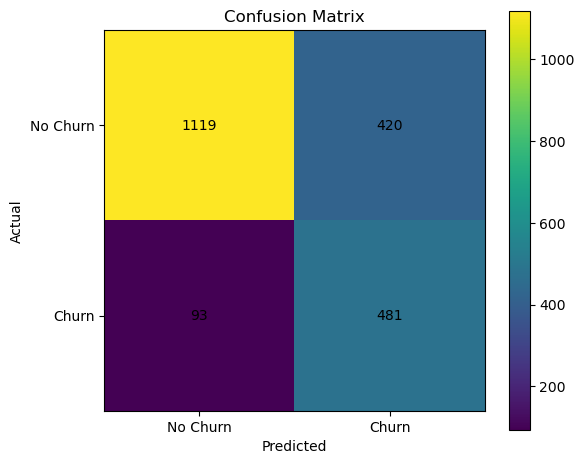

In [505]:
# DIAGRAM
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ['No Churn', 'Churn']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# [[TN FP]
#  [FN TP]]